# Apply DyadPredictor to Real Methylation Data

## 1. Imports and setup

In [84]:
import numpy as np
import sys
from pathlib import Path

parent_path = Path.cwd().parent
if str(parent_path) not in sys.path:
    sys.path.insert(0, str(parent_path))

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from tqdm import tqdm
from scipy.signal import find_peaks
import json

from nuctool.Plotter import Plotter

plot = Plotter()

# Sterachis colormap: white → magenta → blue → cyan → lime → darkgreen
# Intended for nucleosome footprint lengths (0–250 bp)
_sterachis_colors = [
    (0/250,   "white"),
    (45/250,  "yellow"),
    (90/250,  "lime"),
    (135/250,  "limegreen"),
    (170/250,  "cyan"),
    (215/250, "blue"),
    (250/250, "darkblue"),
]
cmap_sterachis = mcolors.LinearSegmentedColormap.from_list(
    "Sterachis", _sterachis_colors, N=250
)
cmap_sterachis.set_bad("white")
cmap_sterachis.set_under("white")

import os
print(os.getcwd())

/home/mvenrooij/NucTool/notebooks


## 2. Configuration

In [85]:
model_filename = rf"data/LLM models/test_15000.pt"

encoded_path  = "../nuctool/methylation_occupancy/encoded_reads_chrII_273000_283000.npy"
coverage_path = "../nuctool/methylation_occupancy/coverage_chrII_273000_283000.npy"
nuc_occ_path  = "../nuctool/methylation_occupancy/occupancy_locus(chrII:273000-283000).npy"

chrom, start, end = "chrII", 273000, 283000

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 3. Model architecture

In [86]:
class DyadPredictor(nn.Module):
    def __init__(self, vocab_size=8, embedding_dim=16, hidden_dim=64, num_layers=2,
                 dropout=0.3, conv_layers=2, conv_kernel_size=5, conv_dilations=None):
        super().__init__()
        self.vocab_size = vocab_size
        self.conv_layers = conv_layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        if conv_dilations is None:
            conv_dilations = [1] * conv_layers
        for i in range(conv_layers):
            in_channels = embedding_dim if i == 0 else hidden_dim
            dilation = conv_dilations[i] if i < len(conv_dilations) else 1
            padding = (conv_kernel_size - 1) * dilation // 2
            setattr(self, f"conv{i+1}", nn.Conv1d(in_channels, hidden_dim,
                kernel_size=conv_kernel_size, padding=padding, dilation=dilation))
            setattr(self, f"bn{i+1}", nn.BatchNorm1d(hidden_dim))
        self.lstm = nn.LSTM(hidden_dim, hidden_dim // 2, num_layers=num_layers,
            bidirectional=True, dropout=dropout if num_layers > 1 else 0, batch_first=True)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(hidden_dim // 2, 1))

    def forward(self, x):
        x = self.embedding(x)
        x = x.transpose(1, 2)
        for i in range(self.conv_layers):
            x = torch.relu(getattr(self, f"bn{i+1}")(getattr(self, f"conv{i+1}")(x)))
        x = x.transpose(1, 2)
        x, _ = self.lstm(x)
        return self.fc(x)


def predict_dyads(model, encoded_sequence, threshold=0.2, device="cpu"):
    model.eval()
    with torch.no_grad():
        seq_tensor = torch.LongTensor(encoded_sequence).unsqueeze(0).to(device)
        probs = torch.sigmoid(model(seq_tensor)).squeeze().cpu().numpy()
    return np.where(probs >= threshold)[0].tolist(), probs


FOOTPRINT = 147  # nucleosome footprint in bp

def call_dyad_positions(probs, min_spacing=FOOTPRINT, min_height=0.0,
                        min_relative_height=0.5, window=100, genomic_start=0):
    """
    Call dyad positions, guaranteeing called peaks are at least min_spacing bp apart.

    find_peaks enforces the spacing before any further filtering, so the
    returned positions are always >= min_spacing bp from each other.

    For each candidate peak i, the certainty score is:
        score = probs[i] / sum(probs[all peaks within ±window bp])

    Args:
        probs               : np.ndarray (locus_length,) or (n_reads, locus_length)
        min_spacing         : minimum bp between called dyads (default = 147, one footprint)
        min_height          : absolute minimum probability to be a candidate (default 0.0)
        min_relative_height : minimum fraction of local peak area required (default 0.5)
        window              : half-width in bp for local peak grouping (default 500)
        genomic_start       : genomic coordinate of probs[0] (default 0)

    Returns:
        1D input : (positions, scores) — both np.ndarray
        2D input : list of (positions, scores) tuples, one per read
    """
    if probs.ndim == 1:
        peak_indices, _ = find_peaks(probs, distance=min_spacing, height=min_height)
        if len(peak_indices) == 0:
            return np.array([], dtype=int) + genomic_start, np.array([])

        peak_probs = probs[peak_indices]

        kept_idx    = []
        kept_scores = []
        for i, idx in enumerate(peak_indices):
            nearby     = np.abs(peak_indices - idx) <= window
            total_area = peak_probs[nearby].sum()
            score      = peak_probs[i] / total_area if total_area > 0 else 0.0
            if score >= min_relative_height:
                kept_idx.append(idx)
                kept_scores.append(score)

        return np.array(kept_idx, dtype=int) + genomic_start, np.array(kept_scores)

    else:
        return [call_dyad_positions(row, min_spacing, min_height,
                                    min_relative_height, window, genomic_start)
                for row in probs]

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

def plot_correlation(measured, predicted, ax=None, title=None):
    """
    Scatter plot of predicted vs measured values with R² and Pearson r.

    Parameters
    ----------
    measured : array-like
        Observed/experimental occupancy.
    predicted : array-like
        Model output (e.g. from model_func with fitted parameters).
    ax : matplotlib Axes, optional
        Existing axis to draw into. If None, a new figure is created.
    title : str, optional
    """
    measured = np.asarray(measured).ravel()
    predicted = np.asarray(predicted).ravel()

    if measured.shape != predicted.shape:
        raise ValueError(
            f"Shape mismatch: measured {measured.shape} vs predicted {predicted.shape}"
        )

    # Statistics
    r, p_value = pearsonr(measured, predicted)
    r_squared = r ** 2
    rmse = np.sqrt(np.mean((predicted - measured) ** 2))

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    # Scatter
    ax.scatter(measured, predicted, s=8, alpha=0.4, edgecolor='none')

    # y = x reference line
    lo = min(measured.min(), predicted.min())
    hi = max(measured.max(), predicted.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='y = x')

    # Linear fit line
    slope, intercept = np.polyfit(measured, predicted, 1)
    xs = np.array([lo, hi])
    ax.plot(xs, slope * xs + intercept, 'r-', lw=1.2,
            label=f'fit: y = {slope:.2f}x + {intercept:.2f}')

    ax.set_xlabel('Measured')
    ax.set_ylabel('Predicted')
    ax.set_title(title or 'Segmented Least Squares Fit correlation')
    ax.set_aspect('equal', adjustable='box')

    # Annotation box with stats
    stats_text = (
        f'$R^2$ = {r_squared:.3f}\n'
        f'r = {r:.3f}\n'
        f'RMSE = {rmse:.4f}\n'
        f'n = {len(measured)}'
    )
    ax.text(0.05, 0.95, stats_text, transform=ax.transAxes,
            va='top', ha='left',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', alpha=0.85))

    plt.tight_layout()
    return measured, predicted, slope, intercept, r, r_squared, ax

## 4. Load model

In [88]:
config_path = Path(model_filename).with_suffix(".json")
with open(config_path) as f:
    config = json.load(f)
llm_cfg = config.get("llm", {})

model_params = {
    "vocab_size":      llm_cfg.get("vocab_size", 8),
    "embedding_dim":   llm_cfg.get("embedding_dim", 16),
    "hidden_dim":      llm_cfg.get("hidden_dim", 64),
    "num_layers":      llm_cfg.get("num_layers", 2),
    "dropout":         llm_cfg.get("dropout", 0.3),
    "conv_layers":     llm_cfg.get("conv_layers", 2),
    "conv_kernel_size":llm_cfg.get("conv_kernel_size", 5),
    "conv_dilations":  llm_cfg.get("conv_dilations", None),
}

loaded_model = DyadPredictor(**model_params)
loaded_model.load_state_dict(torch.load(model_filename, map_location=device))
loaded_model = loaded_model.to(device).eval()
print(f"Loaded {model_filename}  ({sum(p.numel() for p in loaded_model.parameters()):,} params)")

Loaded data/LLM models/test_15000.pt  (680,833 params)


## 5. Load and predict on real reads

In [89]:
encoded_array  = np.load(encoded_path)   # (n_reads, locus_length)
coverage_array = np.load(coverage_path)  # (n_reads, locus_length), bool
nuc_occ        = np.load(nuc_occ_path)
locus_length   = end - start

print(f"Loaded {encoded_array.shape[0]} reads, {locus_length} bp")
print(f"Mean coverage: {coverage_array.mean(axis=0).mean():.1%}")

all_probs = np.zeros((len(encoded_array), locus_length), dtype=np.float32)
for i, encoded in enumerate(tqdm(encoded_array, desc="Predicting dyads")):
    _, all_probs[i] = predict_dyads(loaded_model, encoded, device=device)

n_covering = coverage_array.sum(axis=0).clip(min=1)
mean_probs  = (all_probs * coverage_array).sum(axis=0) / n_covering


Loaded 508 reads, 10000 bp
Mean coverage: 98.5%


Predicting dyads: 100%|██████████| 508/508 [00:17<00:00, 29.44it/s]


## 6. Sort reads by Methylation

In [90]:
# Sort reads by methylation fraction (most → least methylated)
read_lengths  = coverage_array.sum(axis=1)
meth_fraction = ((encoded_array > 3) & coverage_array).sum(axis=1) / read_lengths.clip(min=1)
sort_order    = np.argsort(meth_fraction)[::-1]

encoded_array_f  = encoded_array[sort_order]
coverage_array_f = coverage_array[sort_order]
all_probs_f      = all_probs[sort_order]

print(f"Sorted by methylation: max={meth_fraction[sort_order[0]]:.2%}, "
      f"min={meth_fraction[sort_order[-1]]:.2%}, mean={meth_fraction.mean():.2%}")

Sorted by methylation: max=16.08%, min=0.00%, mean=4.16%


## 7. Mean dyad probability

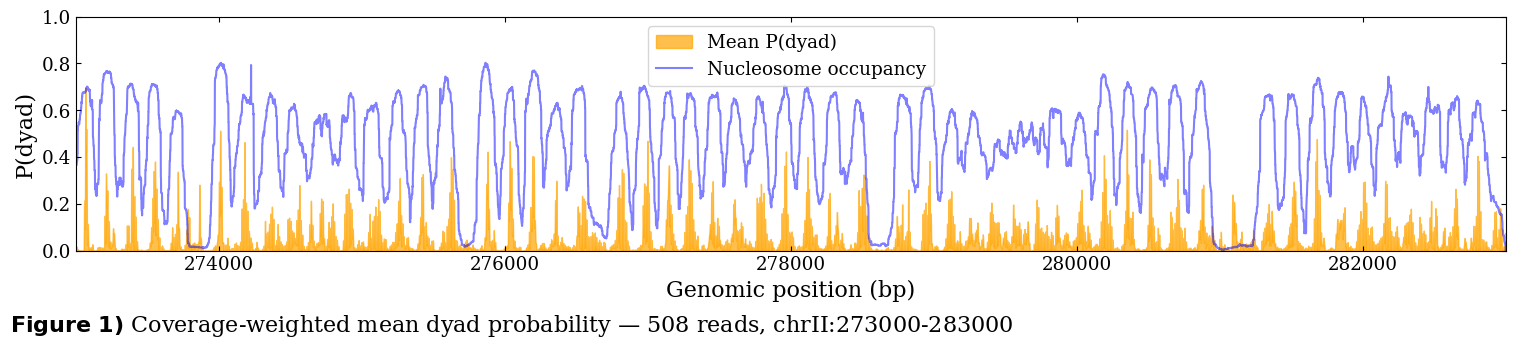

In [91]:
x = np.arange(start, end)

plot.new(fig_size=(15, 3))
plt.fill_between(x, mean_probs, color="orange", alpha=0.7, label="Mean P(dyad)")
plt.plot(x, nuc_occ, color="blue", alpha=0.5, label="Nucleosome occupancy")
plt.xlim(start, end)
plt.ylim(0, 1)
plt.xlabel("Genomic position (bp)")
plt.ylabel("P(dyad)")
plt.legend()
plot.caption(f"Coverage-weighted mean dyad probability — {encoded_array.shape[0]} reads, {chrom}:{start}-{end}")

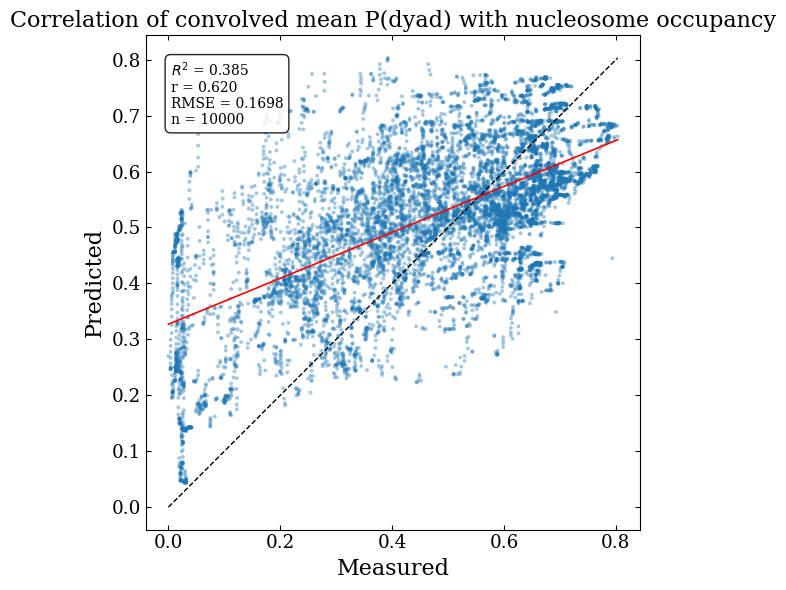

In [140]:
footprint = 147
raw = np.convolve(mean_probs, np.ones(footprint), mode='same')

# Normalise to the same scale as nuc_occ so the shapes are directly comparable
Nuc_mean_occ = raw / raw.max() * nuc_occ.max()

m, p, i, s, r, r2, ax = plot_correlation(nuc_occ, Nuc_mean_occ, title="Correlation of convolved mean P(dyad) with nucleosome occupancy")

xs = np.linspace(0, 1, 100)

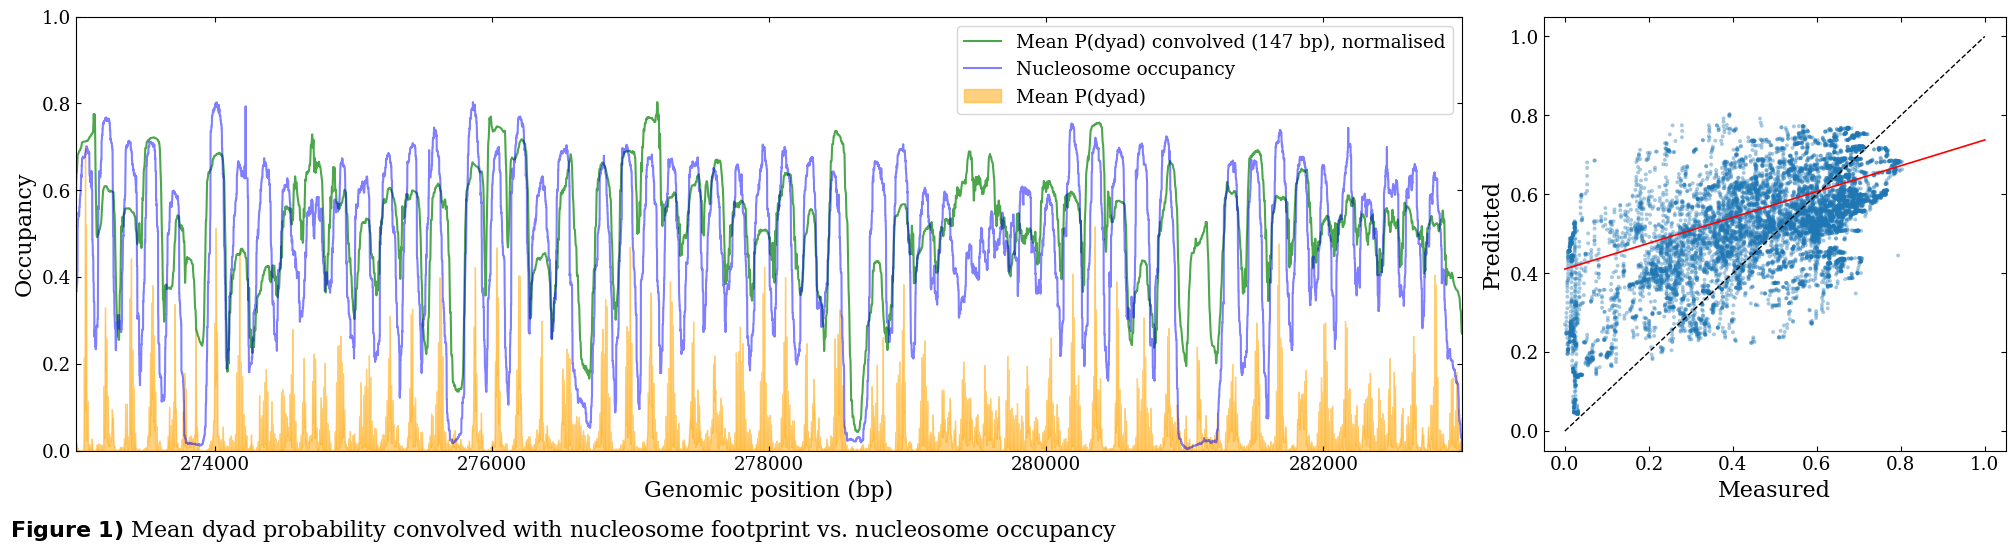

In [141]:
plot = Plotter(fig_size=(20, 5))
plot.new(ncols=2, width_ratios=[3, 1])

ax1, ax2 = plot.axes
ax1.plot(x, Nuc_mean_occ, color="green", alpha=0.7,
         label=f"Mean P(dyad) convolved ({footprint} bp), normalised")
ax1.plot(x, nuc_occ, color="blue", alpha=0.5, label="Nucleosome occupancy")
ax1.fill_between(x, mean_probs, color="orange", alpha=0.5, label="Mean P(dyad)")
ax1.set_xlim(start, end)
ax1.set_ylim(0, 1)
ax1.set_xlabel("Genomic position (bp)")
ax1.set_ylabel("Occupancy")
ax1.legend()

ax2.scatter(m, p, s=8, alpha=0.4, edgecolor='none')
ax2.plot(xs, i + s * xs, 'r-', lw=1.2,
         label=f'Fit: y = {s:.2f}x + {i:.2f}\n$R^2$ = {r2:.3f}\nr = {r:.3f}')
ax2.plot(xs, xs, 'k--', lw=1, label='y = x')
ax2.set_xlabel('Measured')
ax2.set_ylabel('Predicted')

plot.caption("Mean dyad probability convolved with nucleosome footprint vs. nucleosome occupancy")

## 8. Single-molecule dyad probability map

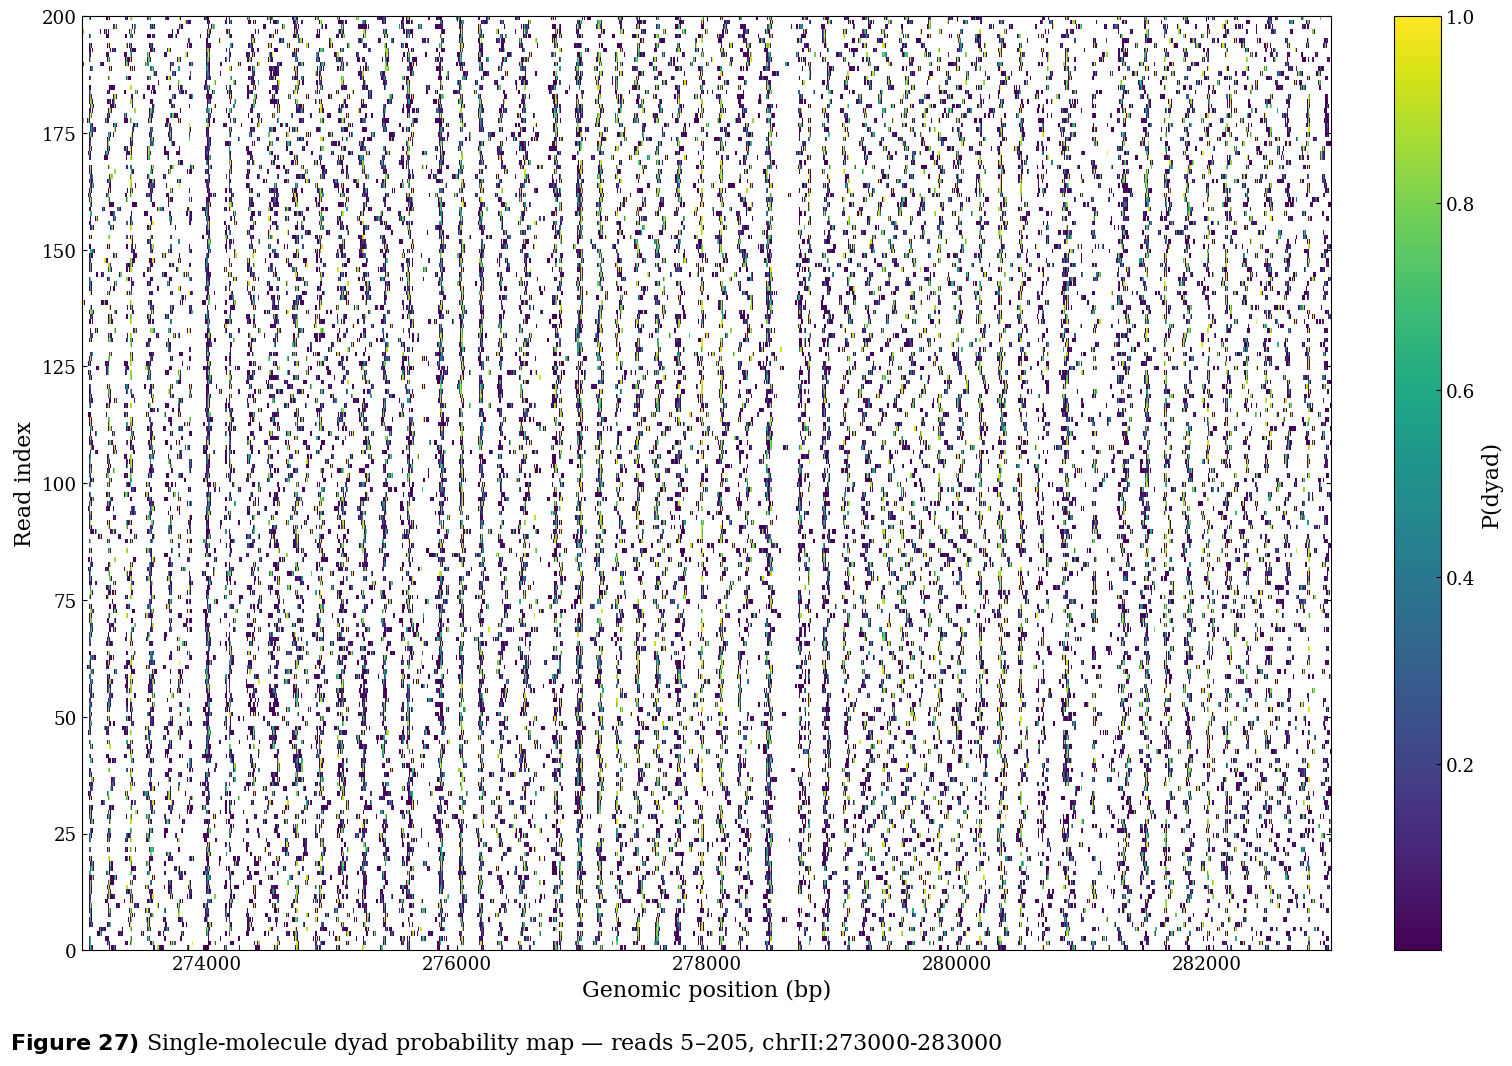

In [121]:
cmap = plt.get_cmap('viridis').copy()
cmap.set_under('white')
cmap.set_bad('white')

read_start, read_end = 5, 205
dyad_matrix = np.where(coverage_array_f, all_probs_f, np.nan)

plot.new(fig_size=(15, 10))
plt.imshow(dyad_matrix[read_start:read_end], aspect='auto', cmap=cmap,
           vmin=0.001, vmax=1, interpolation='nearest',
           extent=[start, end, 0, read_end - read_start])
plt.colorbar(label='P(dyad)')
plt.xlabel("Genomic position (bp)")
plt.ylabel("Read index")
plot.caption(f"Single-molecule dyad probability map — reads {read_start}–{read_end}, {chrom}:{start}-{end}")

## 11. Predicted nucleosome locations

In [95]:
def add_row_spacing(matrix, gap=1):
    """Insert `gap` NaN rows between each row of matrix."""
    n_rows, n_cols = matrix.shape
    spacer = np.full((gap, n_cols), np.nan)
    rows = [np.vstack([matrix[i:i+1], spacer]) for i in range(n_rows)]
    return np.vstack(rows)


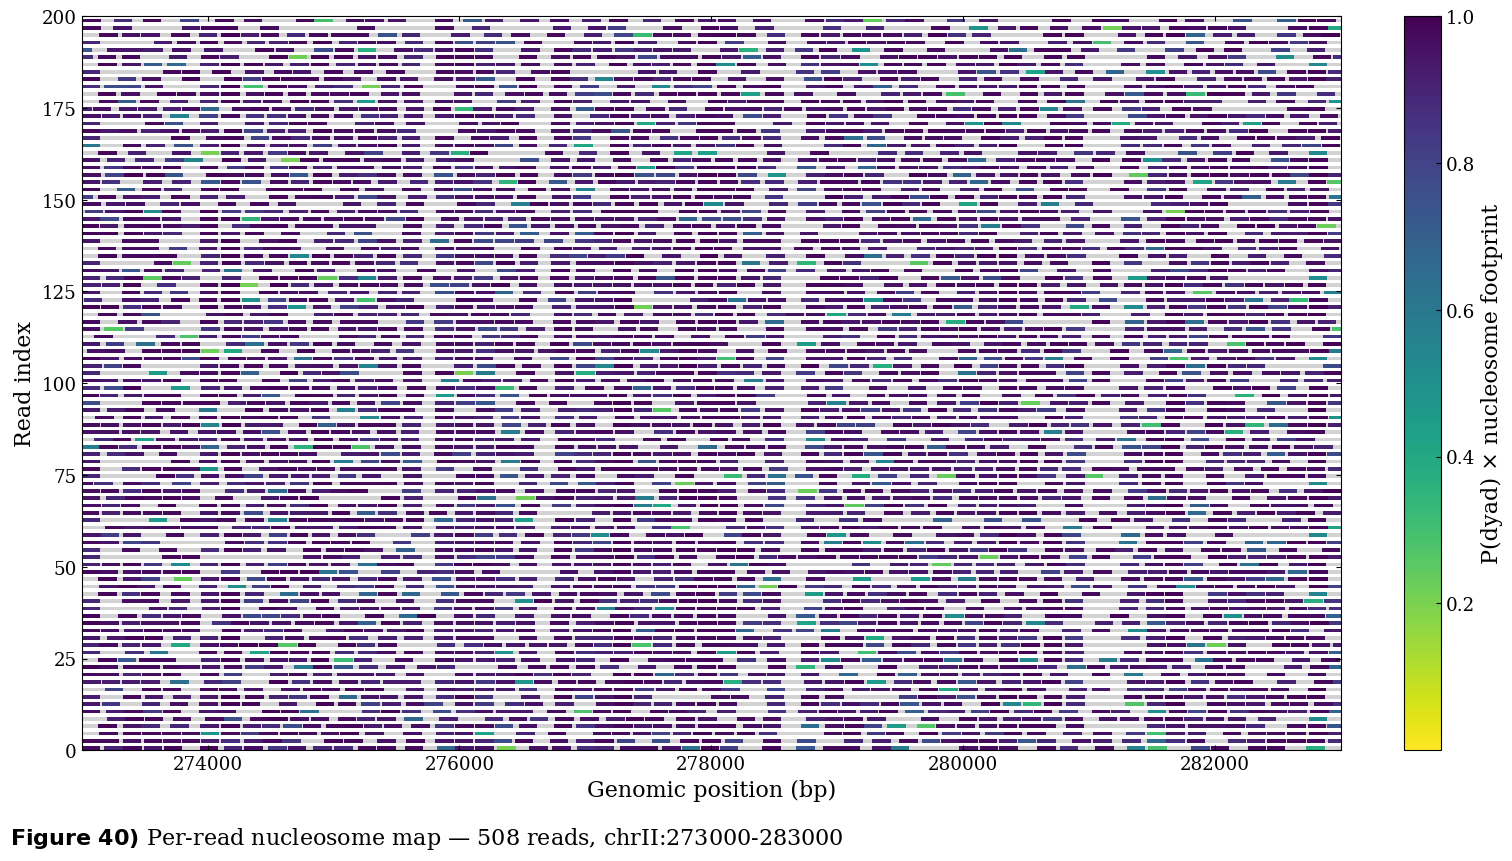

In [135]:
footprint  = 147
half       = footprint // 2
box        = np.ones(footprint)
min_height = 0.2
min_rel    = 0.0

all_dyad_results = call_dyad_positions(
    all_probs_f, min_spacing=footprint, min_height=min_height,
    min_relative_height=min_rel, window=half, genomic_start=0
)

nuc_matrix = np.zeros((len(all_probs_f), locus_length), dtype=np.float32)
for i, (dyad_indices, _) in enumerate(all_dyad_results):
    valid = dyad_indices < locus_length
    dyad_array = np.zeros(locus_length)
    dyad_array[dyad_indices[valid]] = all_probs_f[i, dyad_indices[valid]]
    nuc_matrix[i] = np.convolve(dyad_array, box, mode='same')

spaced_matrix = add_row_spacing(nuc_matrix, gap=1)

cmap_nuc = plt.get_cmap('viridis_r').copy()
cmap_nuc.set_under('lightgray')
cmap_nuc.set_bad('white')

plot.new(fig_size=(15, 8))
plt.imshow(spaced_matrix[read_start:read_end], aspect='auto', cmap=cmap_nuc,
           vmin=1e-6, vmax=1, interpolation='nearest',
           extent=[start, end, 0, read_end - read_start])
plt.colorbar(label='P(dyad) × nucleosome footprint')
plt.xlabel("Genomic position (bp)")
plt.ylabel("Read index")
plot.caption(f"Per-read nucleosome map — {len(nuc_matrix)} reads, {chrom}:{start}-{end}")

## 10. Single-read dyad prediction

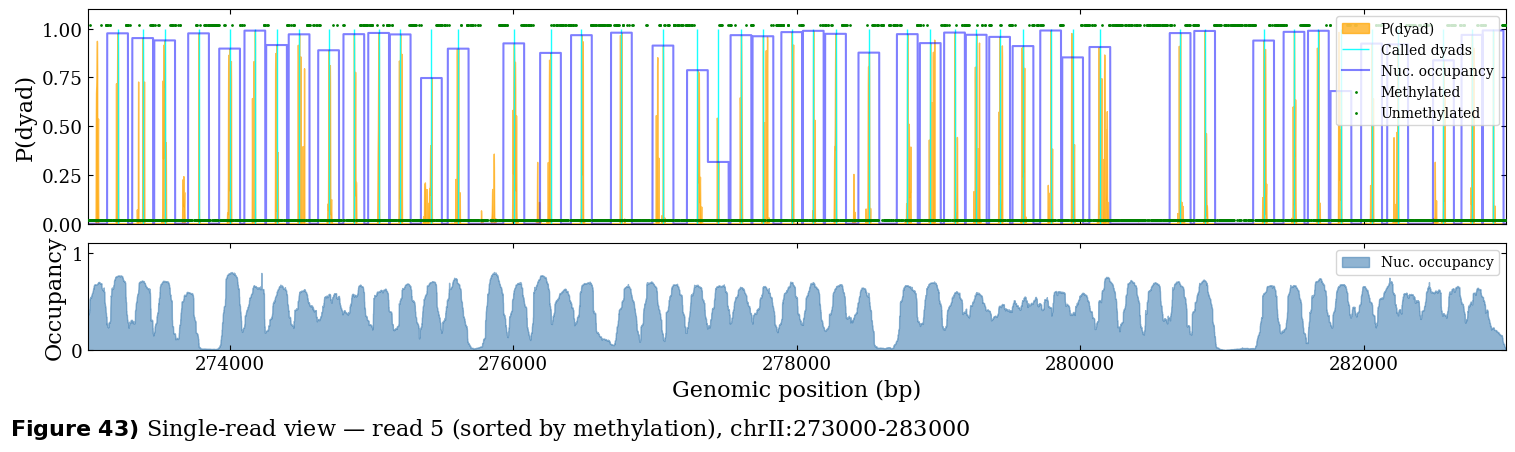

In [ ]:
read_idx = 5   # change to pick a different read

encoded_single = encoded_array_f[read_idx]
probs_single   = all_probs_f[read_idx]
nuc_occ_single = nuc_matrix[read_idx]
dyad_pos = all_dyad_results[read_idx][0]

x = np.arange(start, end)
methylated_mask = (encoded_single == 4) | (encoded_single == 7)
unmethylated_mask = (encoded_single == 0) if (encoded_single == 4).any() else np.zeros_like(encoded_single, dtype=bool)
unmethylated_mask = (encoded_single == 3) if (encoded_single == 3).any() else unmethylated_mask

plot.new(fig_size=(15, 4), nrows=2, sharex=True, height_ratios=[2, 1])
ax_top, ax_bot = plot.axes

# --- top panel: dyad probability + called dyads ---
ax_top.fill_between(x, probs_single, color="orange", alpha=0.7, label="P(dyad)")
ax_top.vlines(dyad_pos+start, ymin=0, ymax=1, color="cyan", linewidth=1.0,
              alpha=0.9, label="Called dyads")
ax_top.plot(x, nuc_occ_single, color="blue", alpha=0.5, label="Nuc. occupancy")
ax_top.scatter(x[methylated_mask],
               np.ones(methylated_mask.sum()) * 1.02,
               color="green", s=1, zorder=3, label="Methylated")
ax_top.scatter(x[unmethylated_mask],
               np.ones(unmethylated_mask.sum()) * 0.02,
               color="green", s=1, zorder=3, label="Unmethylated")
ax_top.set_ylim(0, 1.1)
ax_top.set_ylabel("P(dyad)")
ax_top.legend(loc="upper right", fontsize=10)

# --- bottom panel: nucleosome occupancy ---
ax_bot.fill_between(x, nuc_occ, color="steelblue", alpha=0.6, label="Nuc. occupancy")
ax_bot.set_ylim(0, 1.1)
ax_bot.set_ylabel("Occupancy")
ax_bot.set_xlabel("Genomic position (bp)")
ax_bot.legend(loc="upper right", fontsize=10)

ax_top.set_xlim(start, end)
plot.caption(f"Single-read view — read {read_idx} (sorted by methylation), {chrom}:{start}-{end}")

## 11. Save predictions

## 12. K-means clustering of reads

In [ ]:
from sklearn.cluster import KMeans
from scipy.ndimage import convolve1d
from sklearn.decomposition import PCA


# Smooth the dyad probabilities before clustering to reduce noise
smooth_kernel = np.ones(FOOTPRINT) / FOOTPRINT
features = convolve1d(all_probs_f.astype(np.float32), smooth_kernel, axis=1)

n_clusters = 4   # adjust as needed
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(features)

print(f"Cluster sizes: { {k: (labels==k).sum() for k in range(n_clusters)} }")

Cluster sizes: {0: np.int64(14), 1: np.int64(100), 2: np.int64(195), 3: np.int64(199)}


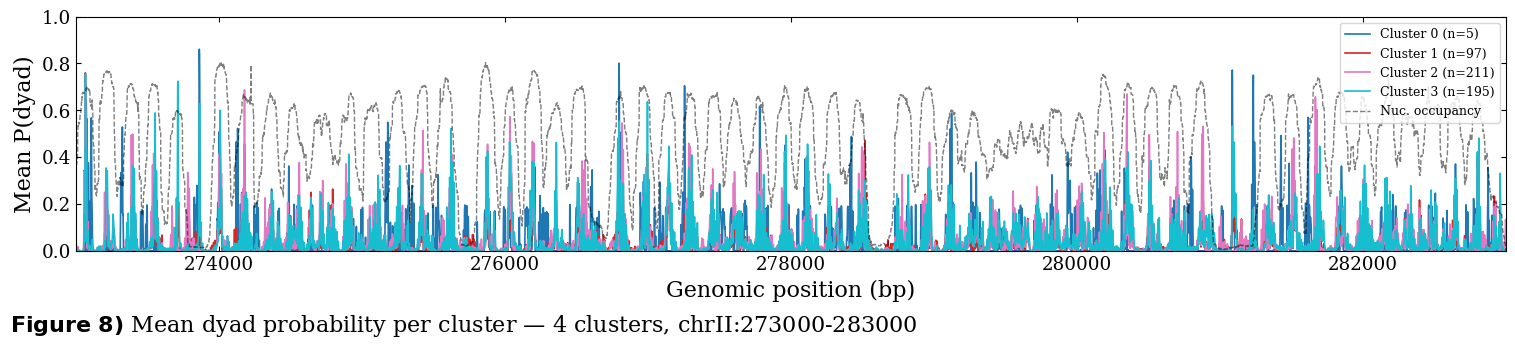

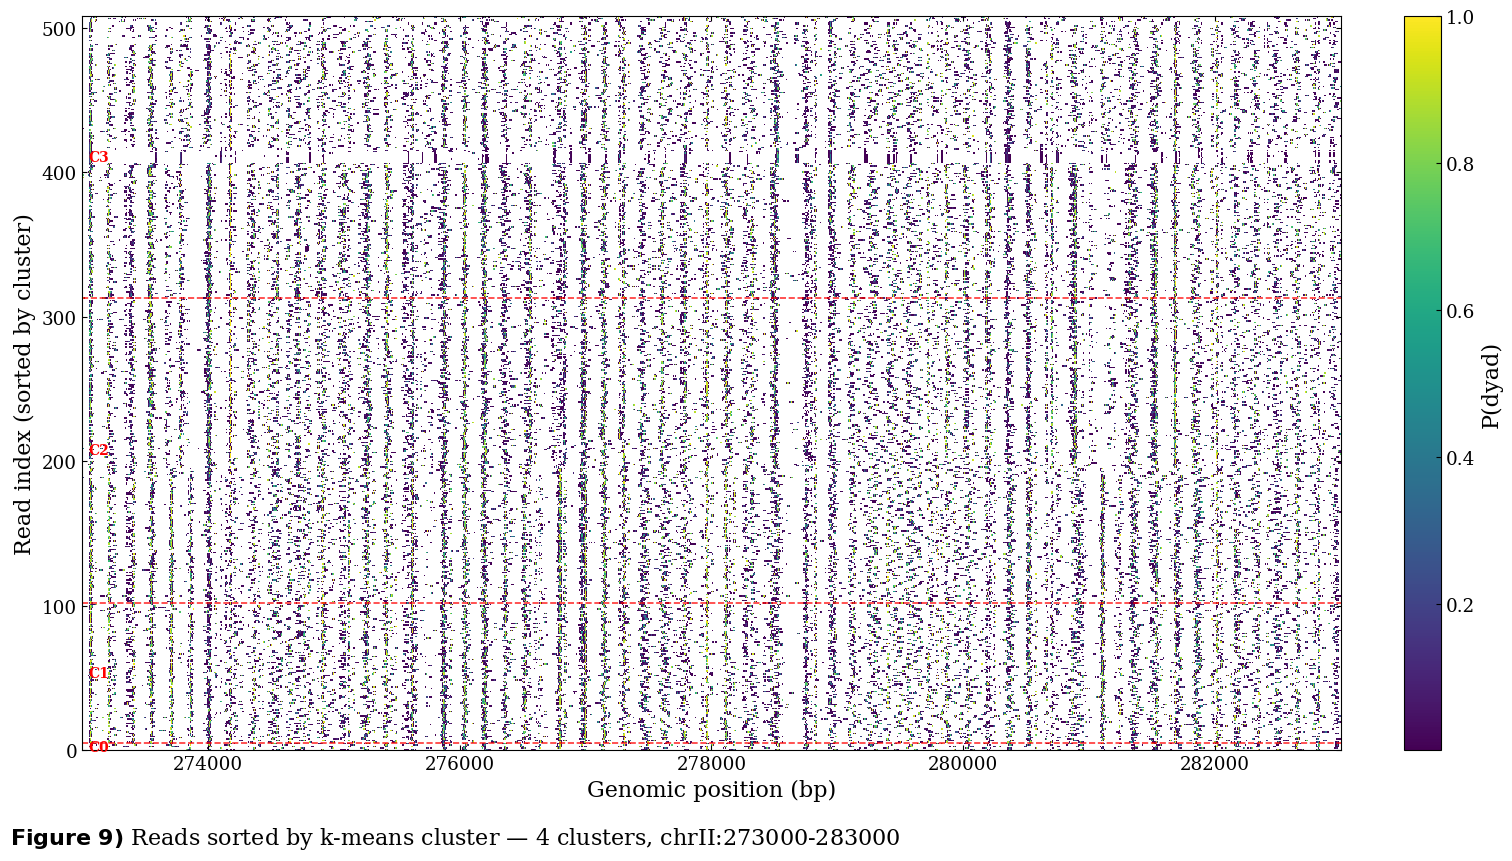

In [149]:
x = np.arange(start, end)
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

# --- Panel 1: mean dyad probability per cluster ---
plot.new(fig_size=(15, 3))
for k in range(n_clusters):
    mask = labels == k
    mean_k = all_probs_f[mask].mean(axis=0)
    plt.plot(x, mean_k, color=colors[k], lw=1.2, label=f"Cluster {k} (n={mask.sum()})")
plt.plot(x, nuc_occ, color='black', lw=1, linestyle='--', alpha=0.5, label="Nuc. occupancy")
plt.xlim(start, end)
plt.ylim(0, 1)
plt.xlabel("Genomic position (bp)")
plt.ylabel("Mean P(dyad)")
plt.legend(fontsize=9)
plot.caption(f"Mean dyad probability per cluster — {n_clusters} clusters, {chrom}:{start}-{end}")

# --- Panel 2: dyad probability heatmap sorted by cluster ---
cluster_order = np.argsort(labels)   # group reads by cluster
sorted_probs  = np.where(coverage_array_f[cluster_order], all_probs_f[cluster_order], np.nan)

cmap_heat = plt.get_cmap('viridis').copy()
cmap_heat.set_under('white')
cmap_heat.set_bad('white')

plot.new(fig_size=(15, 8))
ax = plt.gca()
img = ax.imshow(sorted_probs, aspect='auto', cmap=cmap_heat,
                vmin=0.001, vmax=1, interpolation='nearest',
                extent=[start, end, 0, len(sorted_probs)])
plt.colorbar(img, label='P(dyad)')

# Draw horizontal lines between clusters
boundaries = np.where(np.diff(labels[cluster_order]))[0] + 1
for b in boundaries:
    ax.axhline(b, color='red', linewidth=1.2, linestyle='--', alpha=0.8)

# Label clusters on y-axis
prev = 0
for b in np.append(boundaries, len(labels)):
    cluster_id = labels[cluster_order[prev]]
    ax.text(start + 50, (prev + b) / 2, f"C{cluster_id}",
            color='red', fontsize=10, va='center', fontweight='bold')
    prev = b

ax.set_xlabel("Genomic position (bp)")
ax.set_ylabel("Read index (sorted by cluster)")
plot.caption(f"Reads sorted by k-means cluster — {n_clusters} clusters, {chrom}:{start}-{end}")

## 13. Dyad spacing distribution

Total inter-dyad spacings: 23532
Mean: 211.6 bp,  Median: 173.0 bp,  Std: 111.9 bp


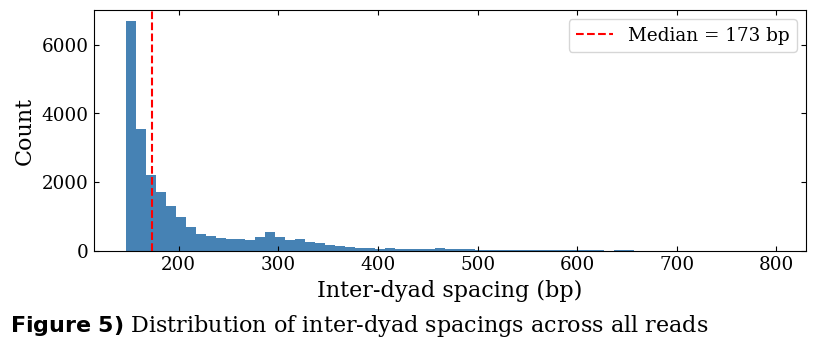

In [146]:
# --- Analysis 1: inter-dyad spacing ---
# Call dyads for all reads and collect consecutive spacings.
# Expected nucleosome repeat length (NRL) in yeast is ~165 bp.

all_dyad_results = call_dyad_positions(
    all_probs_f, min_spacing=FOOTPRINT, min_height=0.2,
    min_relative_height=0.5, window=100, genomic_start=0
)

spacings = []
for dyad_pos, _ in all_dyad_results:
    if len(dyad_pos) >= 2:
        spacings.extend(np.diff(np.sort(dyad_pos)).tolist())

spacings = np.array(spacings)
print(f"Total inter-dyad spacings: {len(spacings)}")
print(f"Mean: {spacings.mean():.1f} bp,  Median: {np.median(spacings):.1f} bp,  Std: {spacings.std():.1f} bp")

plot.new(fig_size=(8, 3))
plt.hist(spacings, bins=np.arange(FOOTPRINT, 800, 10), color='steelblue', edgecolor='none')
plt.axvline(np.median(spacings), color='red', linestyle='--', lw=1.5,
            label=f'Median = {np.median(spacings):.0f} bp')
plt.xlabel("Inter-dyad spacing (bp)")
plt.ylabel("Count")
plt.legend()
plot.caption("Distribution of inter-dyad spacings across all reads")

## 14. Methylation asymmetry around dyads

Dyads used for pileup: 22409
Mean absolute asymmetry (left vs right): 0.01385


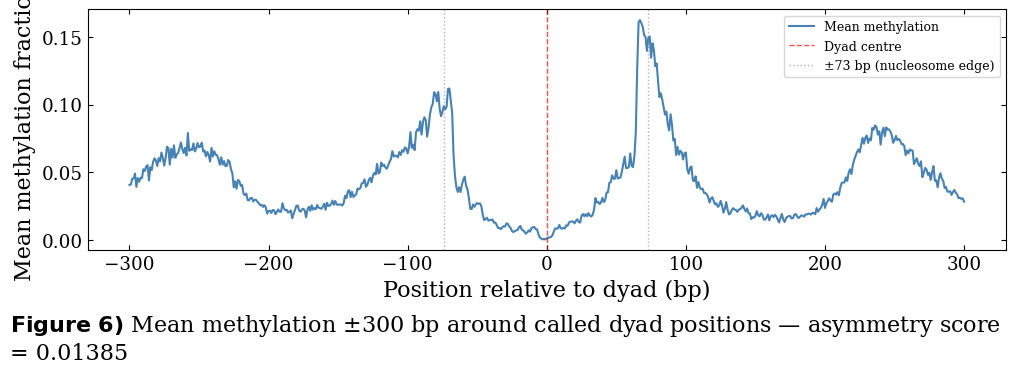

In [147]:
# --- Analysis 2: methylation asymmetry around dyads ---
# For each called dyad, extract the methylation pattern in a window ±window_half bp.
# Average across all dyads → symmetric if nucleosome is symmetric,
# asymmetric if there is a preferred entry/exit direction.

window_half = 300
positions   = np.arange(-window_half, window_half + 1)

meth_sum = np.zeros(len(positions))
cov_sum  = np.zeros(len(positions))

for read_idx, (dyad_pos, _) in enumerate(all_dyad_results):
    encoded = encoded_array_f[read_idx]
    covered = coverage_array_f[read_idx]
    for dyad in dyad_pos:
        lo = dyad - window_half
        hi = dyad + window_half + 1
        if lo < 0 or hi > locus_length:
            continue
        meth_window = (encoded[lo:hi] > 3).astype(float)
        cov_window  = covered[lo:hi].astype(float)
        meth_sum += meth_window * cov_window
        cov_sum  += cov_window

mean_meth_around_dyad = np.where(cov_sum > 0, meth_sum / cov_sum, np.nan)
print(f"Dyads used for pileup: {int(cov_sum[window_half])}")

# Asymmetry score: difference between right and left half
left  = mean_meth_around_dyad[:window_half]
right = mean_meth_around_dyad[window_half+1:][::-1]   # mirror
asymmetry = np.nanmean(np.abs(right - left))
print(f"Mean absolute asymmetry (left vs right): {asymmetry:.5f}")

plot.new(fig_size=(10, 3))
plt.plot(positions, mean_meth_around_dyad, color='steelblue', lw=1.5, label='Mean methylation')
plt.axvline(0,  color='red',  linestyle='--', lw=1, alpha=0.7, label='Dyad centre')
plt.axvline(-FOOTPRINT//2, color='gray', linestyle=':', lw=1, alpha=0.6, label='±73 bp (nucleosome edge)')
plt.axvline( FOOTPRINT//2, color='gray', linestyle=':', lw=1, alpha=0.6)
plt.xlabel("Position relative to dyad (bp)")
plt.ylabel("Mean methylation fraction")
plt.legend(fontsize=9)
plot.caption(f"Mean methylation ±{window_half} bp around called dyad positions — "
             f"asymmetry score = {asymmetry:.5f}")

## 15. Methylation vs sequence contribution to predictions

Running model (with meth vs seq only): 100%|██████████| 100/100 [00:09<00:00, 10.70it/s]


Correlation between meth and seq-only predictions: r = 0.2308
Mean |delta| = 0.04603


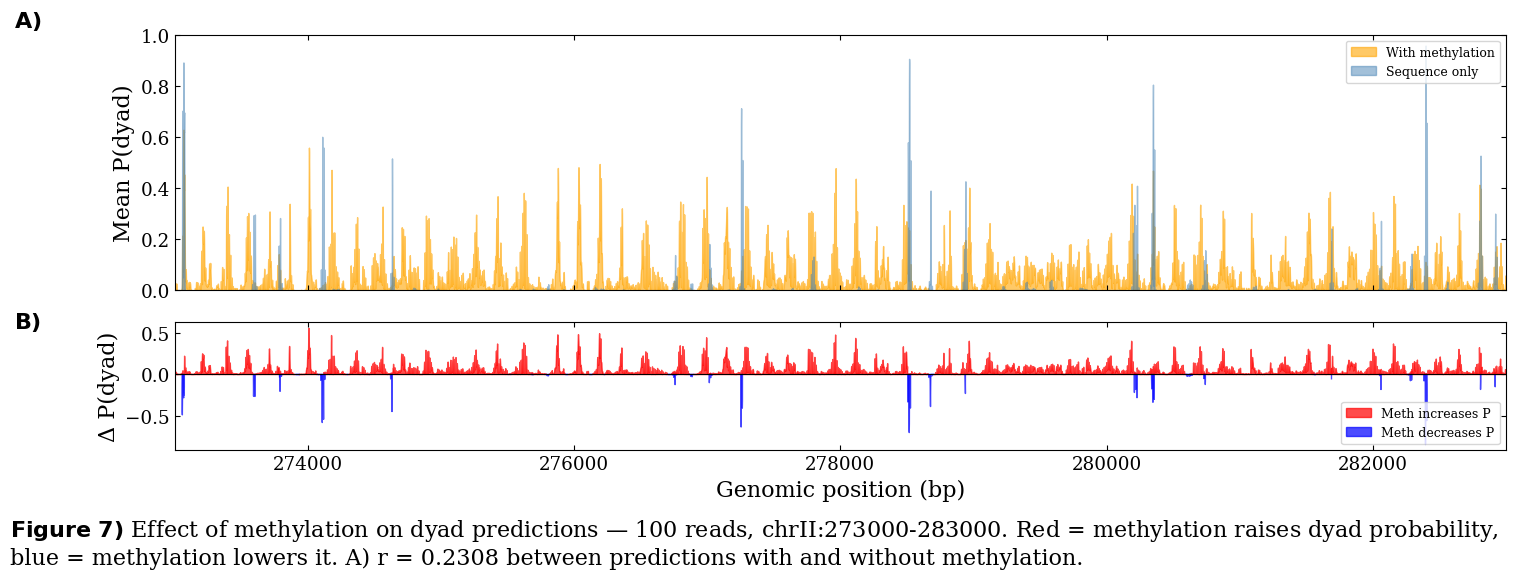

In [148]:
# --- Analysis 3: methylation vs sequence contribution ---
# Run the model twice per read:
#   (a) original encoding (values 0-7, methylation present)
#   (b) sequence-only   (values 4-7 mapped to 0-3 → methylation stripped)
# The difference in predictions shows where methylation matters.

n_sample = min(100, len(encoded_array_f))   # use subset for speed

probs_with_meth = np.zeros((n_sample, locus_length), dtype=np.float32)
probs_seq_only  = np.zeros((n_sample, locus_length), dtype=np.float32)

for i in tqdm(range(n_sample), desc="Running model (with meth vs seq only)"):
    enc     = encoded_array_f[i]
    enc_seq = enc.copy()
    enc_seq[enc_seq > 3] -= 4   # strip methylation: a→A, c→C, g→G, t→T

    _, probs_with_meth[i] = predict_dyads(loaded_model, enc,     device=device)
    _, probs_seq_only[i]  = predict_dyads(loaded_model, enc_seq, device=device)

delta = probs_with_meth - probs_seq_only   # positive = meth increases dyad prob

x = np.arange(start, end)
mean_with = probs_with_meth.mean(axis=0)
mean_seq  = probs_seq_only.mean(axis=0)
mean_delta = delta.mean(axis=0)

# Pearson correlation between the two mean profiles
from scipy.stats import pearsonr
r, _ = pearsonr(mean_with, mean_seq)
print(f"Correlation between meth and seq-only predictions: r = {r:.4f}")
print(f"Mean |delta| = {np.abs(mean_delta).mean():.5f}")

plot.new(fig_size=(15, 5), nrows=2, sharex=True, height_ratios=[2, 1])
ax1, ax2 = plot.axes

ax1.fill_between(x, mean_with, color='orange', alpha=0.6, label='With methylation')
ax1.fill_between(x, mean_seq,  color='steelblue', alpha=0.5, label='Sequence only')
ax1.set_ylim(0, 1); ax1.set_ylabel("Mean P(dyad)")
ax1.legend(fontsize=9)
ax1.set_title(f"r = {r:.4f} between predictions with and without methylation")

ax2.fill_between(x, mean_delta, where=mean_delta > 0, color='red',   alpha=0.7, label='Meth increases P')
ax2.fill_between(x, mean_delta, where=mean_delta < 0, color='blue',  alpha=0.7, label='Meth decreases P')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel("Δ P(dyad)")
ax2.set_xlabel("Genomic position (bp)")
ax2.legend(fontsize=9)

ax1.set_xlim(start, end)
plot.caption(f"Effect of methylation on dyad predictions — {n_sample} reads, {chrom}:{start}-{end}. "
             f"Red = methylation raises dyad probability, blue = methylation lowers it.")

## 16. K-means on dyad spacing vs consensus dyad positions

In [150]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.ndimage import convolve1d

# --- Build dyad position vectors ---
# For each read: place the dyad probability at each called position (0 elsewhere),
# then smooth with a Gaussian-like kernel so nearby positions contribute.
# This captures WHERE dyads are called, not just how many.

smooth_sigma = 20   # bp, controls positional tolerance
smooth_kernel = np.exp(-0.5 * (np.arange(-3*smooth_sigma, 3*smooth_sigma+1) / smooth_sigma)**2)
smooth_kernel /= smooth_kernel.sum()

dyad_vectors = np.zeros((len(all_probs_f), locus_length), dtype=np.float32)
for i, (dyad_pos, _) in enumerate(all_dyad_results):
    valid = dyad_pos < locus_length
    dyad_vectors[i, dyad_pos[valid]] = all_probs_f[i, dyad_pos[valid]]
dyad_vectors = convolve1d(dyad_vectors, smooth_kernel, axis=1)

# --- Consensus dyad positions from mean prediction ---
consensus_pos, _ = call_dyad_positions(
    mean_probs, min_spacing=FOOTPRINT, min_height=0.05,
    min_relative_height=0.3, window=200, genomic_start=start
)
print(f"Consensus dyad positions: {len(consensus_pos)}")

# Smooth consensus vector for comparison
consensus_vec = np.zeros(locus_length, dtype=np.float32)
consensus_vec[consensus_pos - start] = mean_probs[consensus_pos - start]
consensus_vec = convolve1d(consensus_vec, smooth_kernel)

# --- PCA + k-means ---
pca = PCA(n_components=10)
pca_coords = pca.fit_transform(dyad_vectors)
print(f"Variance explained by first 5 PCs: {pca.explained_variance_ratio_[:5].round(3)}")

n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels = kmeans.fit_predict(pca_coords[:, :5])
print(f"Cluster sizes: { {k: int((labels==k).sum()) for k in range(n_clusters)} }")

Consensus dyad positions: 47
Variance explained by first 5 PCs: [0.053 0.045 0.039 0.035 0.032]
Cluster sizes: {0: 145, 1: 157, 2: 143, 3: 63}


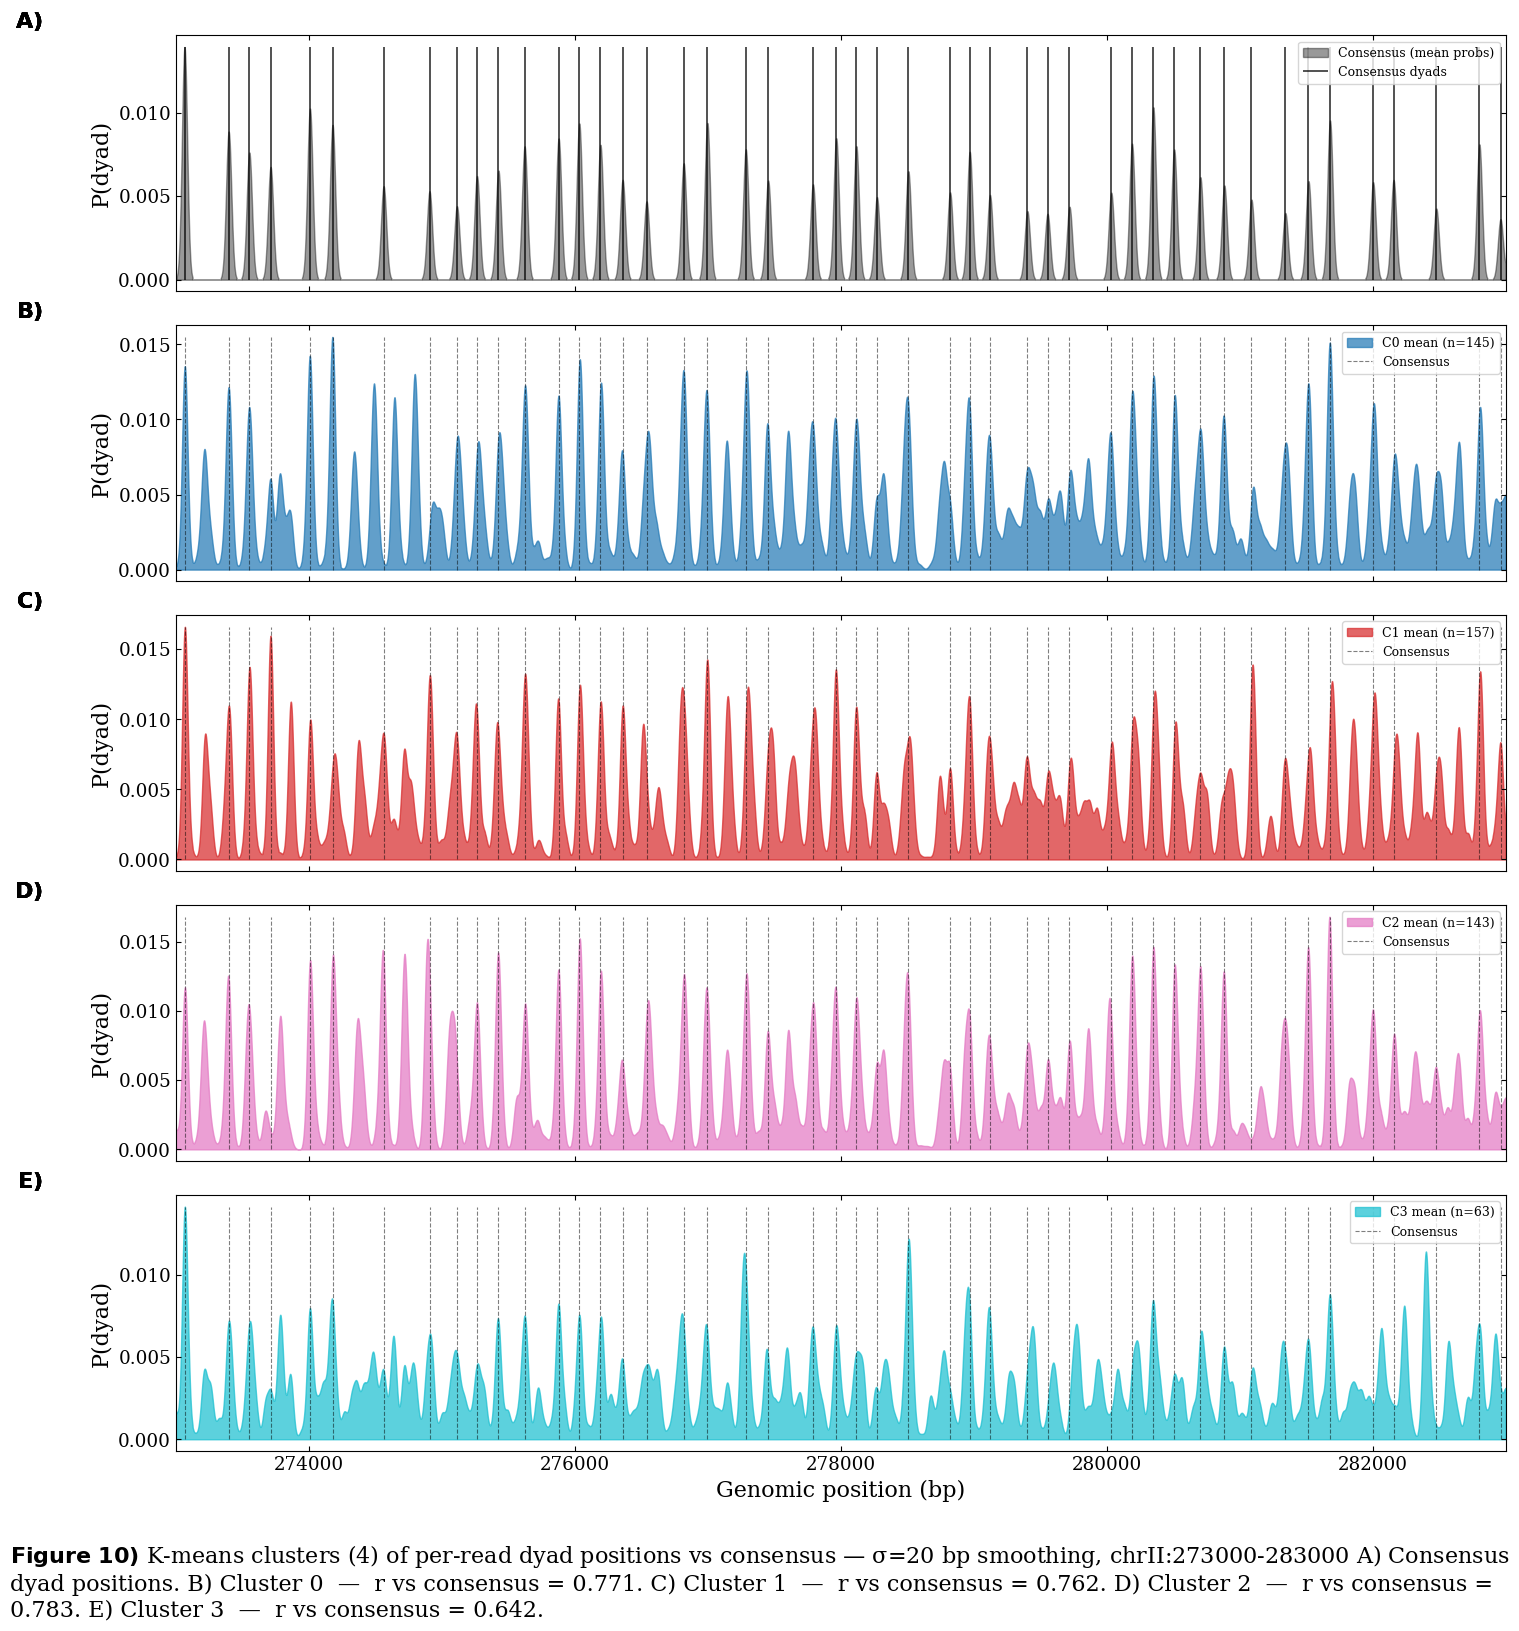

In [151]:
x      = np.arange(start, end)
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))

plot.new(fig_size=(15, 3 * (n_clusters + 1)), nrows=n_clusters + 1, sharex=True)
axes = list(plot.panels)

# --- Top panel: consensus ---
ax0 = axes[0]
ax0.fill_between(x, consensus_vec, color='black', alpha=0.4, label='Consensus (mean probs)')
ax0.vlines(consensus_pos, 0, consensus_vec.max(), color='black',
           lw=1.2, alpha=0.8, label='Consensus dyads')
ax0.set_ylabel("P(dyad)")
ax0.set_title("Consensus dyad positions")
ax0.legend(fontsize=9)

# --- One panel per cluster ---
for k in range(n_clusters):
    ax = axes[k + 1]
    mask      = labels == k
    mean_vec  = dyad_vectors[mask].mean(axis=0)

    # Pearson r between this cluster's mean and the consensus
    from scipy.stats import pearsonr
    r, _ = pearsonr(mean_vec, consensus_vec)

    ax.fill_between(x, mean_vec, color=colors[k], alpha=0.7,
                    label=f"C{k} mean (n={mask.sum()})")
    ax.vlines(consensus_pos, 0, mean_vec.max() if mean_vec.max() > 0 else 0.01,
              color='black', lw=0.8, linestyle='--', alpha=0.5, label='Consensus')
    ax.set_ylabel("P(dyad)")
    ax.set_title(f"Cluster {k}  —  r vs consensus = {r:.3f}")
    ax.legend(fontsize=9)

axes[-1].set_xlabel("Genomic position (bp)")
axes[0].set_xlim(start, end)
plot.caption(f"K-means clusters ({n_clusters}) of per-read dyad positions vs consensus — "
             f"σ={smooth_sigma} bp smoothing, {chrom}:{start}-{end}")

In [97]:
# np.save("data/Model Predictions/predicted_dyad_positions_single_read.npy", dyad_positions_single)
# np.save("data/Model Predictions/predicted_dyad_probabilities_single_read.npy", probs_single)
# print("Saved.")